
# 1. IMPORTS AND SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Enhanced Visualization Settings for Portfolio
sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

print("Environment configured successfully.")

Environment configured successfully.



# 2. DATA LOADING AND CLEANING

In [2]:
print("Ingesting YouTube Shorts dataset...")
df = pd.read_csv("YouTube_Shorts_Engagement_and_Growth_Velocity.csv")

# Display initial shape
print(f"Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Drop non-predictive string columns and derived leakage columns
# We drop 'Views_Per_Day' because it is a direct mathematical derivative of Views and Age
cols_to_drop = ['Video_ID', 'Title', 'Channel_Name', 'Video_URL', 'Views_Per_Day']
df_processed = df.drop(columns=cols_to_drop, errors='ignore')

# Drop any rows with missing values to ensure clean model training
df_processed = df_processed.dropna()

print(f"Processed Shape: {df_processed.shape[0]} rows, {df_processed.shape[1]} columns")
display(df_processed.head())

Ingesting YouTube Shorts dataset...
Initial Shape: 799 rows, 11 columns
Processed Shape: 799 rows, 6 columns


,Views,Likes,Comments,Age_In_Days,Engagement_Rate_%,Description_Length
0,23945,862,120,201,4.1011,4546
1,16456884,129000,4863,342,0.8134,217
2,326589,10000,938,270,3.3492,1505
3,1778131,25000,2261,989,1.5331,1001
4,1307628,7500,443,85,0.6074,1253


# 3. EDA: TARGET DISTRIBUTION & OUTLIER DETECTION

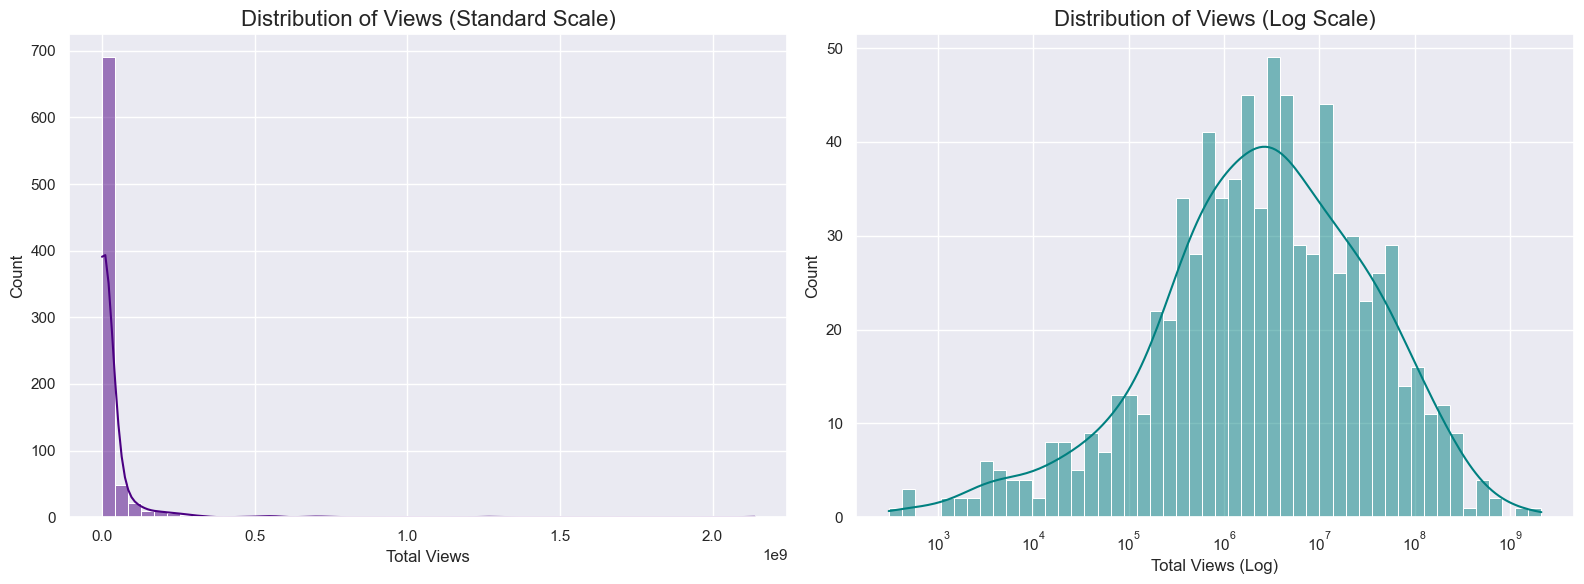

In [3]:
# YouTube views typically follow a heavy power-law (Pareto) distribution.
# We will use a log scale to visualize it properly.

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Standard Histogram
sns.histplot(df_processed['Views'], bins=50, kde=True, color='indigo', ax=ax[0])
ax[0].set_title("Distribution of Views (Standard Scale)")
ax[0].set_xlabel("Total Views")

# Log-Scaled Histogram to handle massive outliers
sns.histplot(df_processed['Views'], bins=50, kde=True, color='teal', ax=ax[1], log_scale=True)
ax[1].set_title("Distribution of Views (Log Scale)")
ax[1].set_xlabel("Total Views (Log)")

plt.tight_layout()
plt.show()

# 4. EDA: CORRELATION HEATMAP & FEATURE RELATIONSHIPS

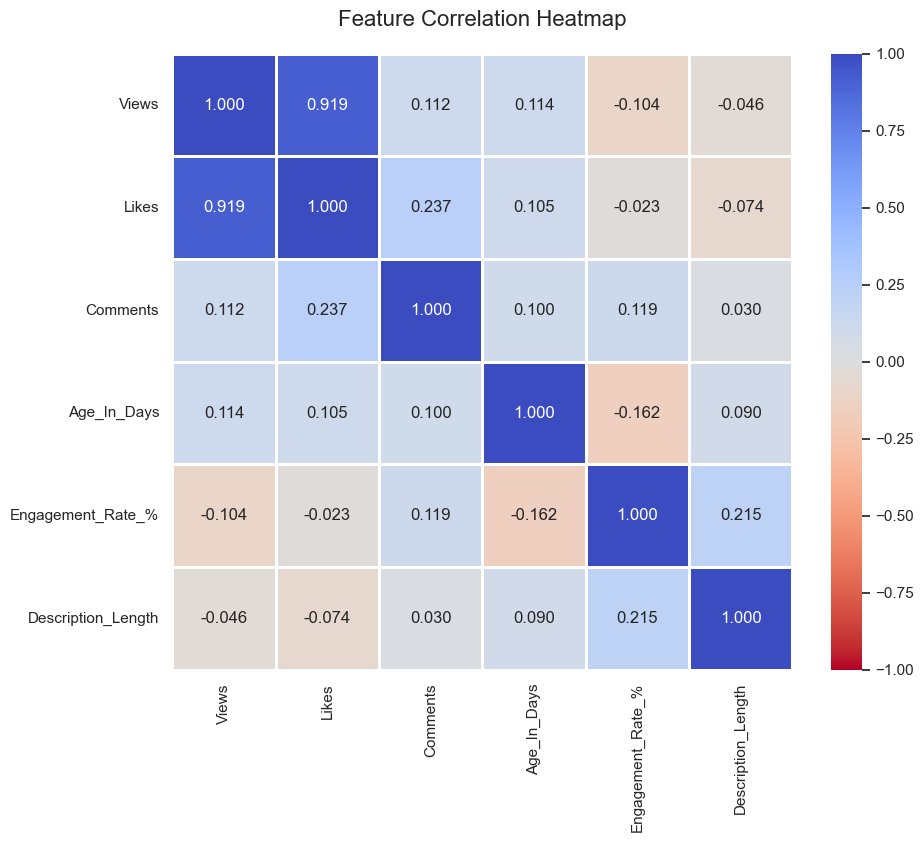

In [4]:

# Identifying multicollinearity before feature selection

corr_matrix = df_processed.corr()

plt.figure(figsize=(10, 8))
# Using a diverging color map to clearly separate positive and negative correlations
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm_r', fmt=".3f", linewidths=1, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", pad=20)
plt.show()

# 5. EDA: PAIRPLOT ANALYSIS

Generating Pairplot (This may take a moment depending on dataset size)...


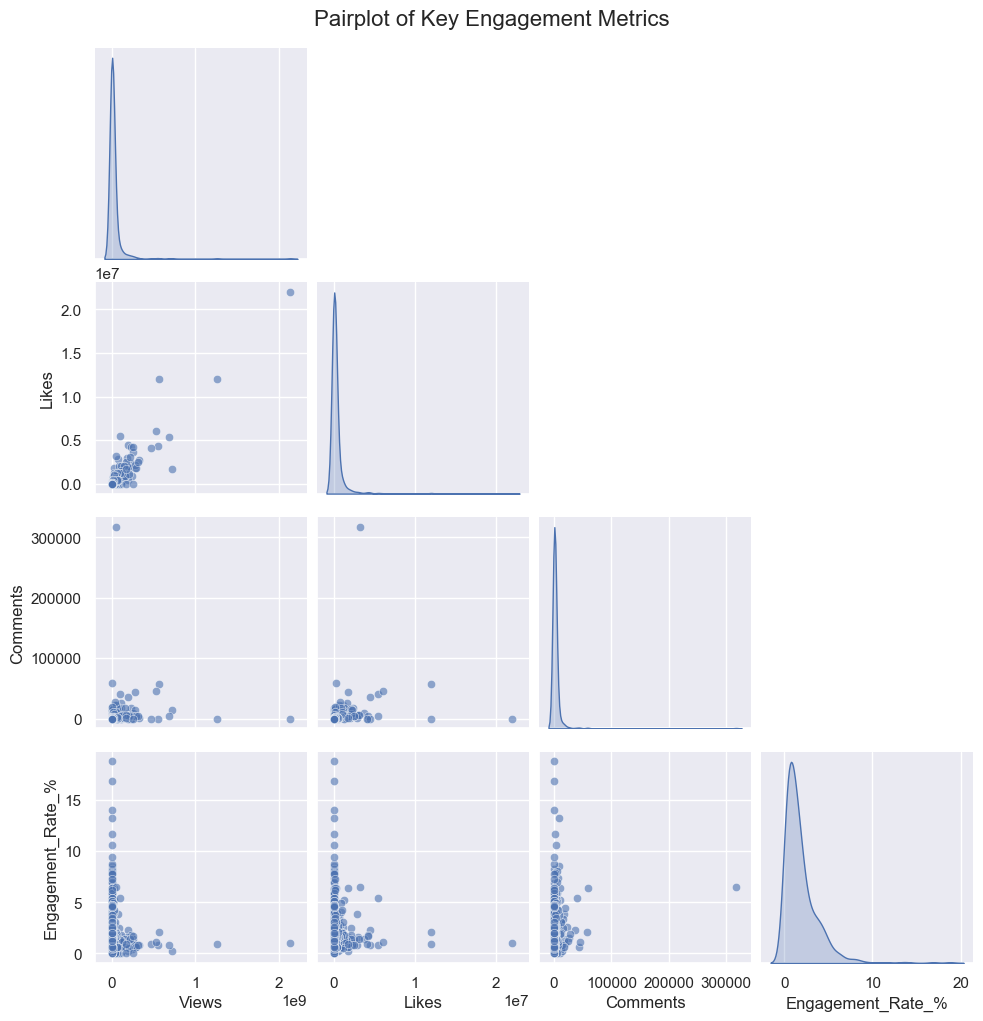

In [5]:

# Visualizing the direct relationship between our strongest features and the target

# Selecting a subset for the pairplot to maintain readability
pairplot_features = ['Views', 'Likes', 'Comments', 'Engagement_Rate_%']

print("Generating Pairplot (This may take a moment depending on dataset size)...")
sns.pairplot(df_processed[pairplot_features], diag_kind='kde', corner=True, plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Key Engagement Metrics", y=1.02, fontsize=16)
plt.show()

# 6. FEATURE ENGINEERING & TRAIN-TEST SPLIT


In [6]:
print("Preparing data arrays for machine learning models...")

# Define Features (X) and Target (y)
X = df_processed.drop(columns=['Views'])
y = df_processed['Views']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features: {list(X_train.columns)}")

Preparing data arrays for machine learning models...
Training Features: ['Likes', 'Comments', 'Age_In_Days', 'Engagement_Rate_%', 'Description_Length']



# 7. FILTER METHOD: MUTUAL INFORMATION


Executing Mutual Information Filter...


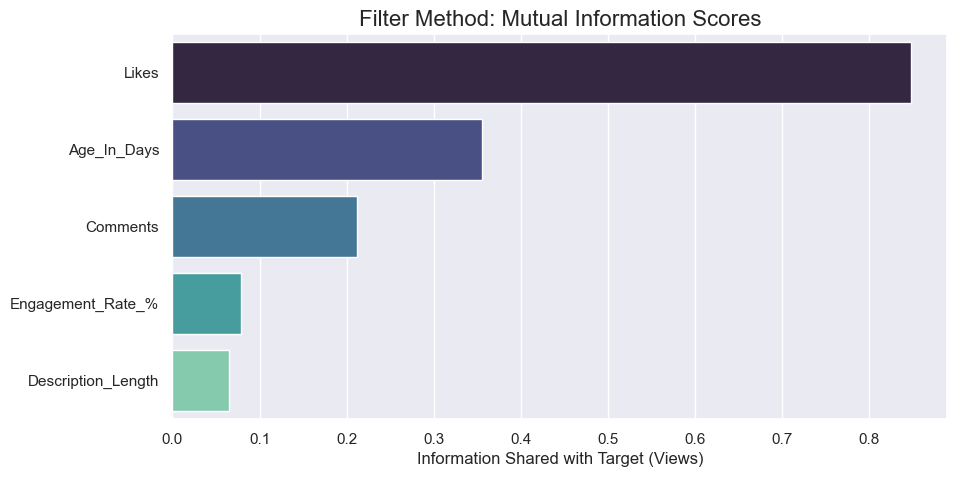

In [7]:
print("Executing Mutual Information Filter...")

# Evaluate non-linear relationships
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

df_mi = pd.DataFrame({'Feature': X_train.columns, 'MI_Score': mi_scores})
df_mi = df_mi.sort_values(by='MI_Score', ascending=False)
top_3_filter = df_mi['Feature'].head(3).tolist()

plt.figure(figsize=(10, 5))
# hue='Feature' and legend=False implemented to comply with seaborn v0.14.0 standards
sns.barplot(x='MI_Score', y='Feature', hue='Feature', data=df_mi, palette='mako', legend=False)
plt.title("Filter Method: Mutual Information Scores")
plt.xlabel("Information Shared with Target (Views)")
plt.ylabel("")
plt.show()


# 8. WRAPPER METHOD: RECURSIVE FEATURE ELIMINATION (RFE)


Executing Recursive Feature Elimination...


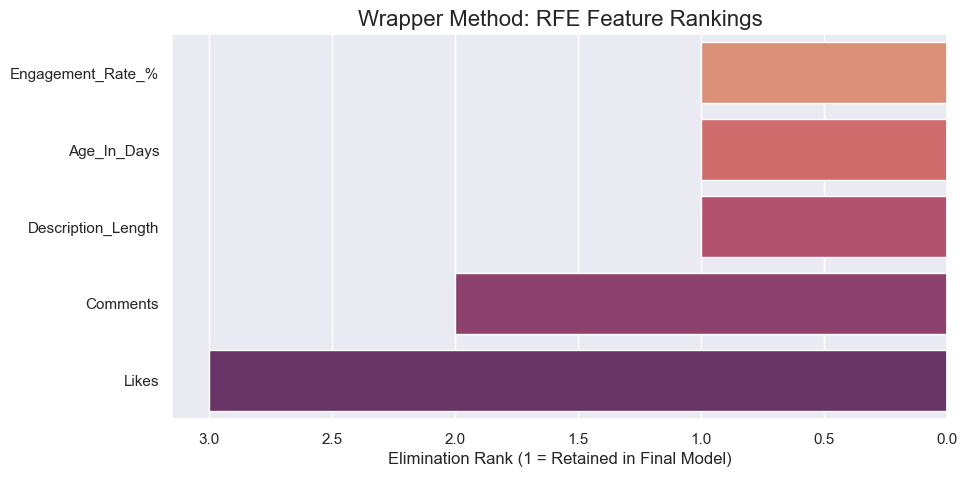

In [8]:

print("Executing Recursive Feature Elimination...")

# Using a baseline Linear Regression model for feature evaluation
estimator = LinearRegression()
rfe = RFE(estimator=estimator, n_features_to_select=3, step=1)
rfe.fit(X_train, y_train)

df_rfe = pd.DataFrame({'Feature': X_train.columns, 'Rank': rfe.ranking_})
df_rfe = df_rfe.sort_values(by='Rank')
top_3_wrapper = df_rfe[df_rfe['Rank'] == 1]['Feature'].tolist()

plt.figure(figsize=(10, 5))
sns.barplot(x='Rank', y='Feature', hue='Feature', data=df_rfe, palette='flare', legend=False)
plt.title("Wrapper Method: RFE Feature Rankings")
plt.xlabel("Elimination Rank (1 = Retained in Final Model)")
plt.ylabel("")
plt.gca().invert_xaxis() 
plt.show()

# 9. EMBEDDED METHOD: RANDOM FOREST


Executing Random Forest Embedded Selection...


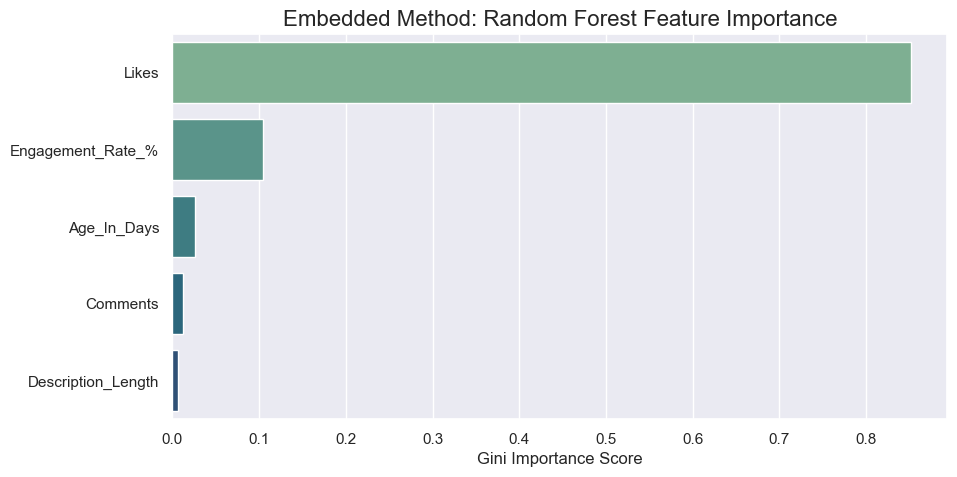

In [11]:
print("Executing Random Forest Embedded Selection...")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

df_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_model.feature_importances_})
df_rf = df_rf.sort_values(by='Importance', ascending=False)
top_3_embedded = df_rf['Feature'].head(3).tolist()

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=df_rf, palette='crest', legend=False)
plt.title("Embedded Method: Random Forest Feature Importance")
plt.xlabel("Gini Importance Score")
plt.ylabel("")
plt.show()

# 10. FINAL EVALUATION: COMPARING PREDICTIVE ACCURACY

Evaluating subset performance against the baseline...


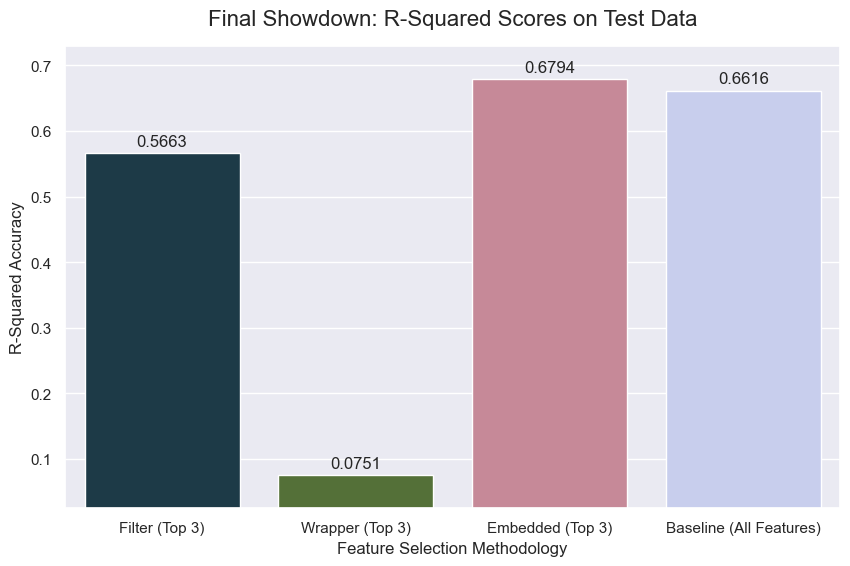

In [12]:

print("Evaluating subset performance against the baseline...")

def evaluate_model(feature_list):
    """Trains a model on the provided feature subset and returns the R2 Score."""
    X_train_sub = X_train[feature_list]
    X_test_sub = X_test[feature_list]
    
    # We use Random Forest for evaluation as Linear Regression struggles with power-law distributions
    eval_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    # FIX: Changed y_test to y_train on the line below
    eval_model.fit(X_train_sub, y_train)
    
    y_pred = eval_model.predict(X_test_sub)
    return r2_score(y_test, y_pred)

# Compile results
results = {
    'Filter (Top 3)': evaluate_model(top_3_filter),
    'Wrapper (Top 3)': evaluate_model(top_3_wrapper),
    'Embedded (Top 3)': evaluate_model(top_3_embedded),
    'Baseline (All Features)': evaluate_model(X_train.columns.tolist())
}

df_results = pd.DataFrame(list(results.items()), columns=['Method', 'R2_Score'])

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Method', y='R2_Score', hue='Method', data=df_results, palette='cubehelix', legend=False)
plt.title("Final Showdown: R-Squared Scores on Test Data", pad=15)
plt.xlabel("Feature Selection Methodology")
plt.ylabel("R-Squared Accuracy")

# Dynamic axis scaling to account for varying R2 scores
plt.ylim(max(df_results['R2_Score'].min() - 0.05, -0.1), min(df_results['R2_Score'].max() + 0.05, 1.0))
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')

for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', padding=3)

plt.show()